In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import gc
from pathlib import Path
from define_data_and_variables import opes_config, opes_hash, data, version

In [2]:
base_dir = Path.cwd()
base_path = base_dir / ".." / ".." / ".." / ".." / "data"

print(data["dn"].lower())
data_name = rf"$A_{{{data["dn"][:3]}}}$"
ylim_max = 0.4
bin_range = (1660, 1730)
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"

biw_dec


In [3]:
base_dir = Path.cwd()
dir = base_dir / f"output/{data["dn"]}/{version}"
output_dir = dir / f"{opes_hash}"
print(output_dir)
hmc_config = opes_config["hmcc"]

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\OPES_full_likelihood\output\biw_dec\0\31559a3e78


In [4]:
color_list = plt.cm.viridis(np.linspace(0, 1, np.min((hmc_config["nch"], 5))))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

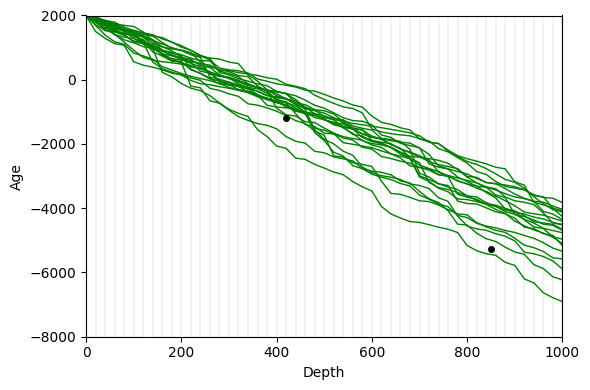

In [5]:

cumulative_sums = np.cumsum(hmc_config["sp"], axis=1) * data["dc"]
zeros = np.zeros((*hmc_config["sp"].shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)

model_ages = data["th"] - age_offsets

# Starting points
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(hmc_config["sp"])
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(np.min(data["d18ort"]), np.max(data["d18ort"]))
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
# plt.savefig(f"{dir}/sp_age_depth.jpg")
plt.show()

In [6]:
base_dir = Path.cwd()
df = np.load(f"{output_dir}/df.npy", mmap_mode = "r")

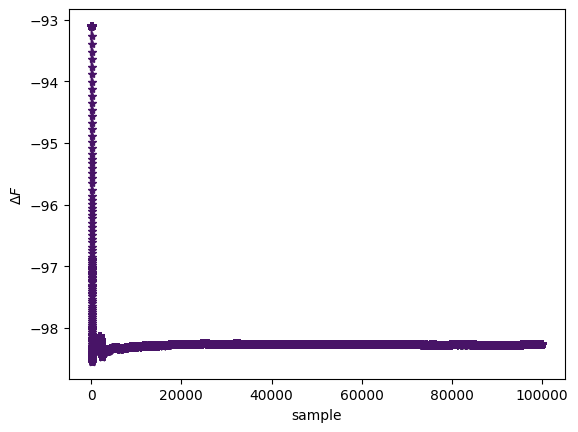

In [7]:
fig, ax = plt.subplots()
ind = -1
chain = 0
x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
sample_delta_F = np.squeeze(df[chain, :, -1])
ax.plot(x[10:], sample_delta_F[10:], '*-', color = temp_colors[1])
plt.xlabel(f"sample")
plt.ylabel(r"$\Delta F$")
# plt.savefig(f"{output_dir}/df_{ind}.jpg")
plt.show()


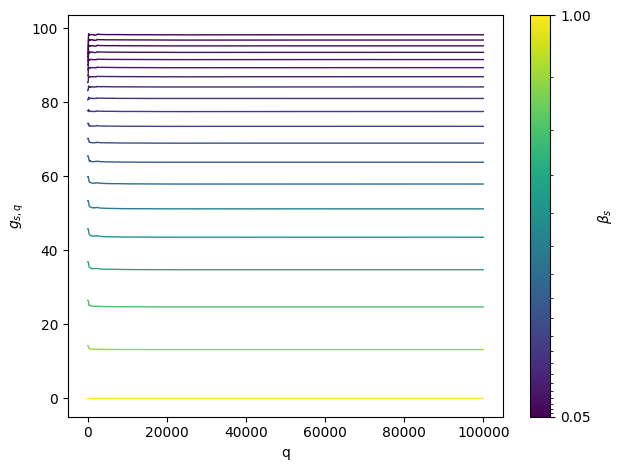

In [8]:
import matplotlib as mpl
fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=min(opes_config['bs']), vmax=max(opes_config['bs']))
cmap = plt.cm.viridis

for k in range(opes_config["nt"]):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:], -sample_delta_F[:], '-', linewidth = 1, color=cmap(norm(opes_config['bs'][k])), label = fr"$\beta_{{{k}}} = $" + f"{opes_config['bs'][k]:.2f}")

plt.xlabel(f"q")
plt.ylabel(r"$g_{s, q}$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\beta_s$")
ticks = [min(opes_config["bs"]), max(opes_config["bs"])]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_minor_locator(
    plt.FixedLocator(opes_config["bs"])
)

plt.tight_layout()
# plt.savefig(f"{output_dir}/gs.jpg")
plt.show()


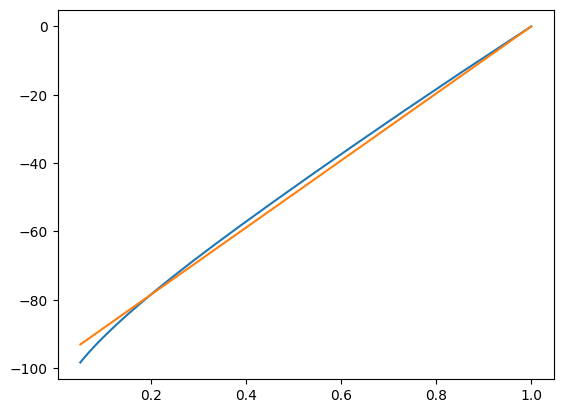

In [9]:
plt.figure()
plt.plot(opes_config["bs"], df[0, 999, :])
plt.plot(opes_config["bs"], opes_config["df"])
plt.show()

In [10]:
del df
gc.collect()

6969

In [11]:
cutout = 10
bias_values = np.load(f"{output_dir}/bias.npy", mmap_mode='r')[:, cutout:]
energy_values = np.load(f"{output_dir}/energy.npy", mmap_mode='r')[:, cutout:]


In [12]:
neff = np.sum(np.exp(bias_values), axis = 1)**2 / np.sum(np.exp(bias_values)**2, axis = 1)
print(neff)

[15659.47941147 15862.21719977 15298.29514522 15593.08812818
 15383.05811978 15498.65977958 15671.41181051 15511.99252241
 15777.18069865 15410.25299221 15052.06344941 15513.11569369
 15161.88996917 15473.76878262 14866.6183135  15425.08912938
 16196.43654975 15770.29696087 15698.84322178 15854.42374172]


In [13]:
print(np.sum(neff))

310678.1816196574


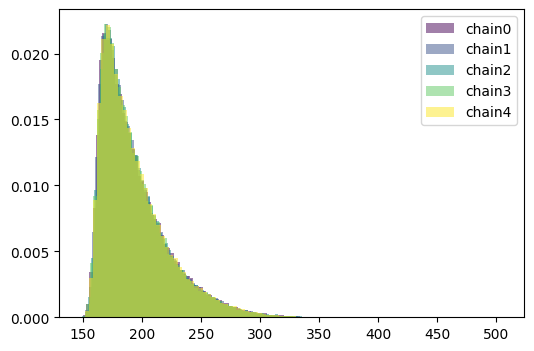

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(np.min((hmc_config["nch"], 5))):
    ax.hist(energy_values[i, cutout:], color = color_list[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
plt.legend()
# plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

In [15]:
print(np.min(energy_values))
print(np.max(bias_values))

146.76154095007496
2.860183740093116


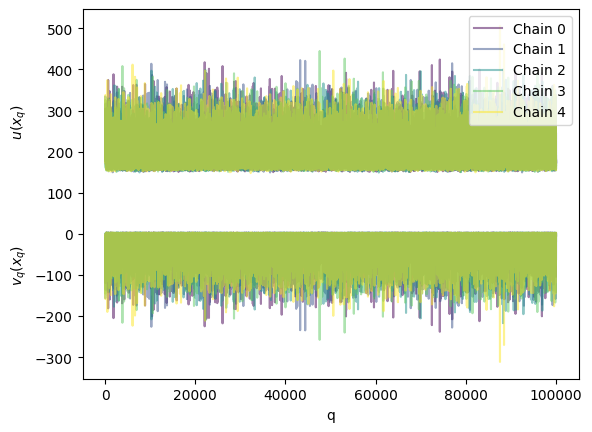

In [16]:
plt.figure()
for i in range(np.min((hmc_config["nch"], 5))):
    plt.plot(np.linspace(cutout, len(bias_values[0, :] + cutout), len(bias_values[i, :])), bias_values[i, :], color = color_list[i], alpha = 0.5, label = f"Chain {i}")
    plt.plot(np.linspace(cutout, len(bias_values[0, :] + cutout), len(bias_values[i, :])), energy_values[i, :], color = color_list[i], alpha = 0.5)
plt.xlabel("q")
plt.ylabel(r"$v_q(x_q)$                        $u(x_q)$")
plt.legend()
# plt.savefig(f"{output_dir}/energy_and_bias.jpg")
plt.show()

In [17]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [18]:
print(az.summary(samples))

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    8.517  5.955   0.814   19.642      0.013    0.009  211807.0  495039.0   
x[1]    8.576  5.803   0.825   19.395      0.012    0.009  225101.0  491340.0   
x[2]    8.884  6.141   0.834   20.389      0.013    0.010  214544.0  482069.0   
x[3]    8.312  5.882   0.808   19.012      0.012    0.012  226816.0  498609.0   
x[4]    9.999  7.573   0.782   24.152      0.017    0.017  198018.0  362942.0   
x[5]    9.349  7.051   0.767   22.748      0.015    0.015  206727.0  418397.0   
x[6]    8.827  6.461   0.776   20.831      0.013    0.012  214813.0  476506.0   
x[7]    8.670  6.344   0.784   20.667      0.013    0.011  222752.0  496100.0   
x[8]    9.142  6.724   0.763   21.830      0.014    0.012  208636.0  441213.0   
x[9]    9.163  6.731   0.798   21.857      0.014    0.012  210852.0  440421.0   
x[10]   8.856  6.485   0.797   20.981      0.013    0.012  219281.0  456582.0   
x[11]   7.991  5.643   0.809

In [19]:
resampled_samples = []
weights = np.exp(bias_values)
for i in range(hmc_config["nch"]):
    weights_i = weights[i, :] / sum(weights[i, :])

    indices = np.random.choice(
        np.arange(0, len(weights_i)),
        size=1000,
        replace=True,
        p=weights_i,
    )
    resampled_samples.append(samples[i, indices, :])
    print(f"Chain {i} done resampling")

resampled_samples = np.array(resampled_samples)

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 5 done resampling
Chain 6 done resampling
Chain 7 done resampling
Chain 8 done resampling
Chain 9 done resampling
Chain 10 done resampling
Chain 11 done resampling
Chain 12 done resampling
Chain 13 done resampling
Chain 14 done resampling
Chain 15 done resampling
Chain 16 done resampling
Chain 17 done resampling
Chain 18 done resampling
Chain 19 done resampling


In [20]:
chain = 0
index = 12
interesting_depth = index * data["dc"]

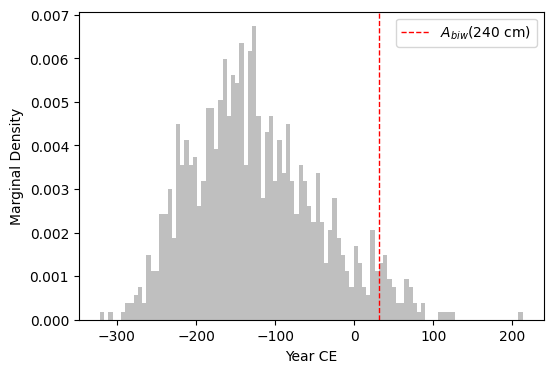

In [21]:
CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[chain][:, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density=True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

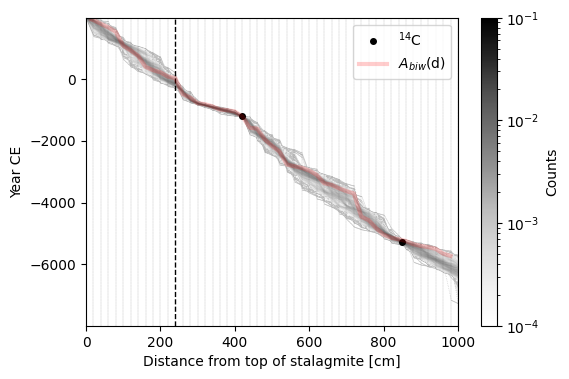

In [22]:
from matplotlib import colors

X = resampled_samples[chain].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if np.max(data["d18ort"]) - np.min(data["d18ort"]) < 2000 else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = data["H"] / 1000
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for j in range(Z):
    C[j, :], _ = np.histogram(A[j, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    linewidth = 0.1 if i != index else 1
    ax.axvline(x=c, color='k', linestyle='--', linewidth = linewidth)


ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["d18od"], data["d18ota"], color = "red", linewidth=3, alpha = 0.2, label = f"{data_name}(d)")

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Counts")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/ad_samples_chain_{chain}.jpg")
plt.show()